# Phase 6: Risk Scoring & Model Fusion

Goal:
Combine multiple anomaly detection models into a single
risk score and determine alert severity.


In [1]:
import numpy as np

iforest_scores = np.load("../data/iforest_scores.npy", allow_pickle=True)
ae_errors = np.load("../data/autoencoder_errors.npy", allow_pickle=True)
lstm_errors = np.load("../data/lstm_sequence_errors.npy", allow_pickle=True)
y = np.load("../data/y_phase2.npy", allow_pickle=True)

print(
    iforest_scores.shape,
    ae_errors.shape,
    lstm_errors.shape,
    y.shape
)


(225711,) (225711,) (225701,) (225711,)


Align LSTM Scores

In [2]:
offset = len(y) - len(lstm_errors)

iforest_scores = iforest_scores[offset:]
ae_errors = ae_errors[offset:]
y = y[offset:]

print("Aligned shapes:", iforest_scores.shape, lstm_errors.shape)


Aligned shapes: (225701,) (225701,)


Normalize Scores (CRITICAL)

Different models → different scales.

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scores = np.vstack([
    -iforest_scores,  # invert (lower = more anomalous)
    ae_errors,
    lstm_errors
]).T

scores_scaled = scaler.fit_transform(scores)


Define Risk Score Formula

Weighted fusion (you can explain this in interviews):

In [4]:
W_IFOREST = 0.4
W_AE = 0.3
W_LSTM = 0.3

risk_score = (
    W_IFOREST * scores_scaled[:, 0] +
    W_AE * scores_scaled[:, 1] +
    W_LSTM * scores_scaled[:, 2]
)


Define Severity Levels

In [5]:
def severity(score):
    if score > 0.7:
        return "HIGH"
    elif score > 0.4:
        return "MEDIUM"
    else:
        return "LOW"

severity_labels = np.array([severity(s) for s in risk_score])


Visualize Risk Distribution

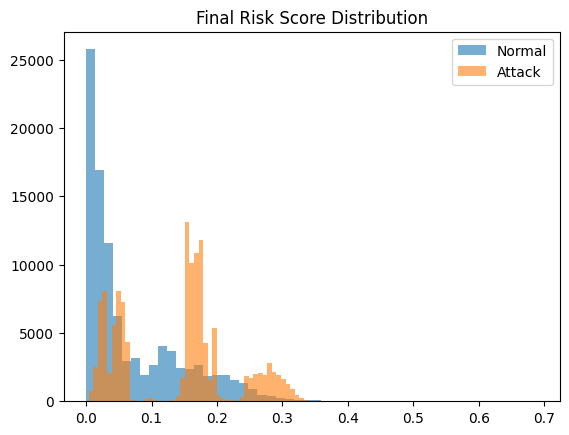

In [6]:
import matplotlib.pyplot as plt

plt.hist(risk_score[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(risk_score[y == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Final Risk Score Distribution")
plt.show()


Evaluate Final System

In [7]:
from sklearn.metrics import classification_report

final_predictions = (risk_score > 0.5).astype(int)
print(classification_report(y, final_predictions))


              precision    recall  f1-score   support

           0       0.43      1.00      0.60     97676
           1       0.00      0.00      0.00    128025

    accuracy                           0.43    225701
   macro avg       0.22      0.50      0.30    225701
weighted avg       0.19      0.43      0.26    225701



In [8]:
np.save("../data/final_risk_scores.npy", risk_score)
np.save("../data/final_severity_labels.npy", severity_labels)

print("Final risk scores saved")


Final risk scores saved


## Phase 6 Summary (Saved)

- Combined Isolation Forest, Autoencoder, and LSTM outputs
- Normalized and fused anomaly scores
- Designed weighted risk scoring logic
- Assigned alert severity levels
- Produced final system-wide detection output


In [9]:
import sys
sys.path.append('../src')
from plot_utils import save_plot

plt.hist(risk_score[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(risk_score[y == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Final Risk Score Distribution")

save_plot("final_risk_score.png", phase="phase6")


Plot saved → ../reports/figures/phase6\final_risk_score.png
